# Transplant Outcomes Surveillance

This notebook builds a surveillance pipeline on publicly available SRTR/OPTN Annual Data Report data to track post-transplant outcomes across kidney, heart, and liver programs from 2013 to 2024. The goal is to detect deviations in outcome trends early — before they surface in published Program-Specific Reports.

Three things are tracked: post-transplant death rates at 6 months and 1 year, kidney Delayed Graft Function (DGF) as a 90-day acute complication indicator, and a short-term vs long-term mortality divergence signal that flags when 6-month deaths are disproportionately high relative to 1-year survival. That last one is the most clinically interesting — it's the signature of an acute procedural issue rather than a patient-mix effect.

Data source: SRTR/OPTN Annual Data Report at srtr.hrsa.gov/adr. Downloaded the data files for the Kidney, Heart, and Liver chapters.

---
## Setup

Imports, output folders, file paths, and sheet names. The SHEET_MAP holds the exact tab names from the SRTR ADR Excel files — these are consistent across organ chapters within the same release year.

In [41]:
# Install dependencies if needed
# !pip install pandas openpyxl matplotlib scipy numpy

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os, json
from datetime import datetime


In [42]:
# ── Configuration ──────────────────────────────────────────────────────────
DATA_DIR = '.' # folder containing the Excel files
OUTPUT_DIR = './outputs'  # where CSVs and charts will be saved
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(f'{OUTPUT_DIR}/charts', exist_ok=True)

FILES = {
    'Kidney': f'{DATA_DIR}/Kidney_Figures_Supporting_Information.xlsx',
    'Heart':f'{DATA_DIR}/Heart_Figures_Supporting_Information.xlsx',
    'Liver':f'{DATA_DIR}/Liver_Figures_Supporting_Information.xlsx',
}

SHEET_MAP = {
    'Kidney': {
        'death_rates': 'KI-F57-tx-adult-Dth-all-C',
        'tx_counts': 'KI-F37-tx-counts-all',
        'dgf_rates': 'KI-F56-tx-adult-DGF',
        'waitlist_mort': 'KI-F25-mort-adult-waiting-all',
    },
    'Heart': {
        'death_rates': 'HR-F56-tx-adult-Dth-all-C',
        'tx_counts': 'HR-F40-tx-counts-all',
        'waitlist_mort': 'HR-F26-mort-adult-waiting-all',
    },
    'Liver': {
        'death_rates': 'LI-F59-tx-adult-Dth-all-C',
        'tx_counts': 'LI-F35-tx-counts-all',
        'waitlist_mort': 'LI-F22-mort-adult-waiting-all',
    },
}

COLORS = {'Kidney': '#1E5FA8', 'Heart': '#C0392B', 'Liver': '#27AE60'}
GRID = '#ECEFF1'
RED_F= '#E74C3C'
YEL_F= '#F39C12'

print(" Configuration set. Ready to run.")


 Configuration set. Ready to run.


---
## Module 1 — data ingestion and cleaning

A simple logging function to record any data quality issues with a timestamp. Every missing value or parsing problem gets written here before anything goes to a stakeholder.

In [43]:
quality_log = []

def log_q(organ, sheet, issue, severity='INFO'):
    quality_log.append({
        'timestamp': datetime.now().isoformat(),
        'organ': organ, 'sheet': sheet,
        'issue': issue, 'severity': severity
    })
    print(f"  [{severity}] {organ}/{sheet}: {issue}")

def read_sheet(filepath, sheet_name, organ):
    """
    Read one SRTR ADR sheet. Skips 8 leading blank columns,
    uses row 0 as header, drops non-numeric Year rows (captions/alt text).
    """
    try:
        raw = pd.read_excel(filepath, sheet_name=sheet_name, header=None)
    except Exception as e:
        log_q(organ, sheet_name, f"Cannot read sheet: {e}", 'ERROR')
        return None

    # Find the column where 'Year' appears in row 0
    year_col = next(
        (j for j in range(raw.shape[1])
         if str(raw.iloc[0, j]).strip().lower() == 'year'), None)
    if year_col is None:
        log_q(organ, sheet_name, "Cannot find 'Year' header", 'ERROR')
        return None

    df = raw.iloc[:, year_col:].copy()
    df.columns = df.iloc[0].astype(str).str.strip()
    df = df.iloc[1:].reset_index(drop=True)
    df = df[pd.to_numeric(df['Year'], errors='coerce').notna()].copy()
    df['Year'] = df['Year'].astype(int)
    return df

print(" Sheet reader defined.")


 Sheet reader defined.


Four extraction functions — one per metric. Each calls `read_sheet`, standardizes column names, converts to numeric, and logs any NaN values. Missing values in the 3-year and 5-year death rate columns are expected for recent cohorts that haven't reached that follow-up interval yet.

In [44]:
def extract_death_rates(organ, filepath):
    sheet = SHEET_MAP[organ]['death_rates']
    df = read_sheet(filepath, sheet, organ)
    if df is None: return None
    rename = {}
    for col in df.columns:
        c = str(col).lower()
        if '6' in c:rename[col] = 'death_6mo_pct'
        elif '1-year' in c or col == '1-year': rename[col] = 'death_1yr_pct'
        elif '3' in c and 'year' in c: rename[col] = 'death_3yr_pct'
        elif '5' in c and 'year' in c: rename[col] = 'death_5yr_pct'
    df = df.rename(columns=rename)
    want = ['Year','death_6mo_pct','death_1yr_pct','death_3yr_pct','death_5yr_pct']
    df = df[[c for c in want if c in df.columns]].copy()
    for c in df.columns[1:]:
        df[c] = pd.to_numeric(df[c], errors='coerce')
        n = df[c].isna().sum()
        if n: log_q(organ, sheet, f"{c}: {n} missing (expected for recent cohorts)")
    df['organ'] = organ
    return df.sort_values('Year').reset_index(drop=True)

def extract_tx_counts(organ, filepath):
    sheet = SHEET_MAP[organ]['tx_counts']
    df = read_sheet(filepath, sheet, organ)
    if df is None: return None
    vol = [c for c in df.columns if c.lower() != 'year'][0]
    df = df[['Year', vol]].rename(columns={vol: 'tx_count'})
    df['tx_count'] = pd.to_numeric(df['tx_count'], errors='coerce')
    df['organ'] = organ
    return df.sort_values('Year').reset_index(drop=True)

def extract_dgf(filepath):
    organ, sheet = 'Kidney', SHEET_MAP['Kidney']['dgf_rates']
    df = read_sheet(filepath, sheet, organ)
    if df is None: return None
    rename = {}
    for col in df.columns:
        c = str(col).lower()
        if 'dgf' in c and 'no' not in c and 'miss' not in c: rename[col] = 'dgf_rate_pct'
        elif 'no' in c and 'dgf' in c:rename[col] = 'no_dgf_pct'
        elif 'miss' in c: rename[col] = 'dgf_missing_pct'
    df = df.rename(columns=rename)
    want = ['Year','dgf_rate_pct','no_dgf_pct','dgf_missing_pct']
    df = df[[c for c in want if c in df.columns]].copy()
    for c in df.columns[1:]:
        df[c] = pd.to_numeric(df[c], errors='coerce')
    df['organ'] = organ
    return df.sort_values('Year').reset_index(drop=True)

def extract_waitlist_mort(organ, filepath):
    sheet = SHEET_MAP[organ].get('waitlist_mort')
    if not sheet: return None
    df = read_sheet(filepath, sheet, organ)
    if df is None: return None
    non_year = [c for c in df.columns if c.lower() != 'year']
    if not non_year: return None
    mort_col = next((c for c in non_year
                     if 'overall' in c.lower() or 'all' in c.lower()), non_year[0])
    df = df[['Year', mort_col]].rename(columns={mort_col: 'waitlist_mort_per100'})
    df['waitlist_mort_per100'] = pd.to_numeric(df['waitlist_mort_per100'], errors='coerce')
    df['organ'] = organ
    return df.sort_values('Year').reset_index(drop=True)

print(" Extraction functions defined.")


 Extraction functions defined.


Run the extractions across all three organs, print a summary, combine into DataFrames, and save to CSV. The quality log goes to JSON as a full audit trail.

In [45]:
# ── Run ingestion ─────────────────────────────────────────────────────────
print("MODULE 1 — Data Ingestion & Cleaning")

dr_frames, tc_frames, wm_frames = [], [], []

for organ, fp in FILES.items():
    print(f"\n[{organ}]")
    dr = extract_death_rates(organ, fp)
    if dr is not None:
        dr_frames.append(dr)
        print(f"   Death rates:{len(dr)} cohort years")
    tc = extract_tx_counts(organ, fp)
    if tc is not None:
        tc_frames.append(tc)
        print(f"   Tx counts:{int(tc['tx_count'].min()):,}–{int(tc['tx_count'].max()):,} per year")
    wm = extract_waitlist_mort(organ, fp)
    if wm is not None:
        wm_frames.append(wm)
        print(f"   Waitlist mort:{len(wm)} years")

print("\n[Kidney — DGF (90-day complication indicator)]")
dgf = extract_dgf(FILES['Kidney'])
if dgf is not None:
    delta = dgf['dgf_rate_pct'].iloc[-1] - dgf['dgf_rate_pct'].iloc[0]
    pct = (delta / dgf['dgf_rate_pct'].iloc[0]) * 100
    print(f"DGF rate: {dgf['dgf_rate_pct'].iloc[0]:.1f}% (2013) → "
          f"{dgf['dgf_rate_pct'].iloc[-1]:.1f}% (2024)  [Δ +{delta:.1f} pp / +{pct:.0f}% relative]")
    print(f"51% relative increase in 90-day acute complications")

# Combine & save
death_df = pd.concat(dr_frames, ignore_index=True)
tx_df= pd.concat(tc_frames, ignore_index=True)
wm_df= pd.concat(wm_frames, ignore_index=True)

death_df.to_csv(f'{OUTPUT_DIR}/death_rates_clean.csv', index=False)
tx_df.to_csv(f'{OUTPUT_DIR}/tx_counts_clean.csv', index=False)
wm_df.to_csv(f'{OUTPUT_DIR}/waitlist_mortality_clean.csv', index=False)
if dgf is not None:
    dgf.to_csv(f'{OUTPUT_DIR}/dgf_rates_clean.csv', index=False)

with open(f'{OUTPUT_DIR}/data_quality_report.json', 'w') as f:
    json.dump({
        'generated': datetime.now().isoformat(),
        'source': 'SRTR/OPTN Annual Data Report — srtr.hrsa.gov/adr/',
        'records': {'death_rates': len(death_df), 'tx_counts': len(tx_df),
                    'waitlist_mortality': len(wm_df),
                    'dgf_rates': len(dgf) if dgf is not None else 0},
        'quality_flags': quality_log
    }, f, indent=2)

print(f"\n CSVs and data quality report saved to {OUTPUT_DIR}/")
print(f"  Quality flags logged: {len(quality_log)}")


MODULE 1 — Data Ingestion & Cleaning

[Kidney]
  [INFO] Kidney/KI-F57-tx-adult-Dth-all-C: death_3yr_pct: 2 missing (expected for recent cohorts)
  [INFO] Kidney/KI-F57-tx-adult-Dth-all-C: death_5yr_pct: 4 missing (expected for recent cohorts)
   Death rates:11 cohort years
   Tx counts:17,658–28,492 per year
   Waitlist mort:12 years

[Heart]
  [INFO] Heart/HR-F56-tx-adult-Dth-all-C: death_3yr_pct: 2 missing (expected for recent cohorts)
  [INFO] Heart/HR-F56-tx-adult-Dth-all-C: death_5yr_pct: 4 missing (expected for recent cohorts)
   Death rates:11 cohort years
   Tx counts:2,554–4,636 per year
   Waitlist mort:12 years

[Liver]
  [INFO] Liver/LI-F59-tx-adult-Dth-all-C: death_3yr_pct: 2 missing (expected for recent cohorts)
  [INFO] Liver/LI-F59-tx-adult-Dth-all-C: death_5yr_pct: 4 missing (expected for recent cohorts)
   Death rates:11 cohort years
   Tx counts:6,455–11,458 per year
   Waitlist mort:12 years

[Kidney — DGF (90-day complication indicator)]
DGF rate: 17.7% (2013) → 26

---
## Module 2 — anomaly detection and signal flagging

Two detection methods run in parallel: Statistical Process Control on death rates, and a short-term vs long-term divergence check. DGF gets its own dedicated surveillance track. The output is a ranked flags table — RED means the deviation warrants immediate review, YELLOW means monitor it.

All three surveillance functions plus the helper utilities. The rolling control limits use a 3-year window so they adapt to gradual secular trends rather than flagging everything against a fixed baseline. The divergence check computes the ratio of 6-month to 1-year death rate — a spike in that ratio is the signature of an acute procedural complication, since something going wrong in surgery kills patients before 6 months while those who survive past that tend to reach 1 year.

In [46]:
def rolling_control_limits(series, window=3):
    """Rolling mean ± 2 SD control limits (min 2 periods to start)."""
    roll_mean = series.rolling(window=window, min_periods=2).mean()
    roll_std= series.rolling(window=window, min_periods=2).std()
    return roll_mean, roll_mean + 2*roll_std, roll_mean - 2*roll_std

def flag_severity(z):
    if pd.isna(z):return 'GREEN'
    if abs(z) > 2.0:return 'RED'
    if abs(z) > 1.5:return 'YELLOW'
    return 'GREEN'

def spc_surveillance(df, organ, metric_col, metric_label, window=3):
    sub = df[df['organ']==organ][['Year',metric_col]].dropna().sort_values('Year').copy()
    if len(sub) < 3: return pd.DataFrame()
    roll_mean, upper, lower = rolling_control_limits(sub[metric_col], window)
    sub['rolling_mean'] = roll_mean
    sub['upper_limit']= upper
    sub['lower_limit']= lower
    roll_std = sub[metric_col].rolling(window, min_periods=2).std()
    sub['deviation_z']= (sub[metric_col] - roll_mean) / roll_std
    sub['flag'] = sub['deviation_z'].abs() > 1.5
    sub['severity'] = sub['deviation_z'].apply(flag_severity)
    sub['direction']= sub['deviation_z'].apply(
        lambda z: 'WORSE' if z>0 else ('BETTER' if z<0 else 'STABLE') if pd.notna(z) else 'STABLE')
    sub['organ']= organ
    sub['metric'] = metric_label
    sub['metric_col'] = metric_col
    return sub

def divergence_surveillance(df, organ):
    """
    Detects disproportionate short-term vs long-term mortality.
    Signature of acute procedural complications (e.g. surgical tool issue):
    6-month death rate spikes while 1-year rate is less affected.
    """
    sub = df[df['organ']==organ][['Year','death_6mo_pct','death_1yr_pct']].dropna().sort_values('Year').copy()
    if len(sub) < 3: return pd.DataFrame()
    sub['ratio_6mo_to_1yr']= sub['death_6mo_pct'] / sub['death_1yr_pct']
    ratio_mean = sub['ratio_6mo_to_1yr'].mean()
    ratio_std = sub['ratio_6mo_to_1yr'].std()
    sub['ratio_z'] = (sub['ratio_6mo_to_1yr'] - ratio_mean) / ratio_std
    sub['divergence_flag']= sub['ratio_z'].abs() > 1.5
    sub['divergence_severity']= sub['ratio_z'].apply(flag_severity)
    sub['organ'] = organ
    return sub

def dgf_surveillance(dgf_df):
    """
    DGF = dialysis within 7 days post-transplant.
    The primary 90-day acute complication metric for kidney transplants.
    Rising DGF is the most direct quantitative analogue to the surgical
    tool scenario — detectable before long-term survival curves move.
    """
    sub = dgf_df[['Year','dgf_rate_pct']].dropna().sort_values('Year').copy()
    roll_mean, upper, lower = rolling_control_limits(sub['dgf_rate_pct'])
    sub['rolling_mean'] = roll_mean
    sub['upper_limit']= upper
    sub['lower_limit']= lower
    roll_std = sub['dgf_rate_pct'].rolling(3, min_periods=2).std()
    sub['deviation_z']= (sub['dgf_rate_pct'] - roll_mean) / roll_std
    sub['severity'] = sub['deviation_z'].apply(flag_severity)
    sub['organ']= 'Kidney'
    sub['metric'] = 'Delayed Graft Function (90-day)'
    return sub

print(" Anomaly detection functions defined.")


 Anomaly detection functions defined.


Run all three detection methods, compile every flag into a single ranked table, and save to CSV.

In [47]:
# ── Run anomaly detection ──────────────────────────────────────────────────
print("MODULE 2 — Anomaly Detection & Signal Flagging")

organs = ['Kidney', 'Heart', 'Liver']

# 1. SPC
print("\n[SPC Control Chart Analysis]")
spc_frames = []
for organ in organs:
    for col, label in [('death_6mo_pct','6-Month Death Rate'),
                        ('death_1yr_pct','1-Year Death Rate')]:
        res = spc_surveillance(death_df, organ, col, label)
        if not res.empty:
            spc_frames.append(res)
            r = res[res['severity']=='RED']
            y = res[res['severity']=='YELLOW']
            print(f"  {organ} / {label}: {len(r)} RED, {len(y)} YELLOW")

trend_df = pd.concat(spc_frames, ignore_index=True)

# 2. Divergence
print("\n[Short-term vs Long-term Divergence]")
div_frames = []
for organ in organs:
    res = divergence_surveillance(death_df, organ)
    if not res.empty:
        div_frames.append(res)
        flagged = res[res['divergence_flag']]
        print(f"  {organ}: {len(flagged)} divergence event(s)")
        for _, row in flagged.iterrows():
            print(f"{int(row['Year'])}: ratio={row['ratio_6mo_to_1yr']:.3f} "
                  f"[{row['divergence_severity']}] "
                  f"6mo={row['death_6mo_pct']:.2f}% vs 1yr={row['death_1yr_pct']:.2f}%")

div_df = pd.concat(div_frames, ignore_index=True)

# 3. DGF
print("\n[DGF Surveillance — Kidney 90-day]")
dgf_trend = dgf_surveillance(dgf)
r_dgf = dgf_trend[dgf_trend['severity']=='RED']
y_dgf = dgf_trend[dgf_trend['severity']=='YELLOW']
print(f"  DGF: {len(r_dgf)} RED, {len(y_dgf)} YELLOW flags")
print(f"  Trend: +9.0 pp over 2013–2024 = +51% relative increase")

# 4. Compile all flags
flag_parts = []

flagged_spc = trend_df[trend_df['flag']].copy()
flagged_spc['signal_type']= 'SPC Control Limit'
flagged_spc['description']= (flagged_spc['organ'] + ' ' + flagged_spc['metric']
                                + ' exceeded threshold in ' + flagged_spc['Year'].astype(str))
flag_parts.append(flagged_spc[['Year','organ','metric','severity',
                                'signal_type','description','direction','deviation_z']])

flagged_div = div_df[div_df['divergence_flag']].copy()
flagged_div['signal_type']= 'Short-term/Long-term Divergence'
flagged_div['metric'] = '6mo vs 1yr Death Rate Ratio'
flagged_div['severity'] = flagged_div['divergence_severity']
flagged_div['direction']= 'WORSE'
flagged_div['description']= (flagged_div['organ']
    + ': Disproportionate 6-month mortality in ' + flagged_div['Year'].astype(str)
    + ' — pattern consistent with acute procedural complications')
flagged_div['deviation_z']= flagged_div['ratio_z']
flag_parts.append(flagged_div[['Year','organ','metric','severity',
                                'signal_type','description','direction','deviation_z']])

flagged_dgf = dgf_trend[dgf_trend['severity'].isin(['RED','YELLOW'])].copy()
if not flagged_dgf.empty:
    flagged_dgf['signal_type']= 'DGF Surveillance'
    flagged_dgf['metric'] = 'Delayed Graft Function Rate'
    flagged_dgf['direction']= 'WORSE'
    flagged_dgf['description']= ('Kidney DGF exceeded control limit in '
                                   + flagged_dgf['Year'].astype(str)
                                   + ' — elevated 90-day acute complication rate')
    flag_parts.append(flagged_dgf[['Year','organ','metric','severity',
                                    'signal_type','description','direction','deviation_z']])

flags_df = pd.concat(flag_parts, ignore_index=True).sort_values(
    ['severity','Year'], ascending=[True,False])

# Save
trend_df.to_csv(f'{OUTPUT_DIR}/trend_analysis.csv', index=False)
div_df.to_csv(f'{OUTPUT_DIR}/divergence_analysis.csv', index=False)
dgf_trend.to_csv(f'{OUTPUT_DIR}/dgf_trend_analysis.csv',index=False)
flags_df.to_csv(f'{OUTPUT_DIR}/flagged_signals.csv',index=False)

print(f"\n── Summary ────────────────────────────────────")
print(f"  Total signals flagged : {len(flags_df)}")
print(f"  RED  (immediate review): {len(flags_df[flags_df['severity']=='RED'])}")
print(f"  YELLOW (monitor)       : {len(flags_df[flags_df['severity']=='YELLOW'])}")
print(f"\n All outputs saved to {OUTPUT_DIR}/")


MODULE 2 — Anomaly Detection & Signal Flagging

[SPC Control Chart Analysis]
  Kidney / 6-Month Death Rate: 0 RED, 0 YELLOW
  Kidney / 1-Year Death Rate: 0 RED, 0 YELLOW
  Heart / 6-Month Death Rate: 0 RED, 0 YELLOW
  Heart / 1-Year Death Rate: 0 RED, 0 YELLOW
  Liver / 6-Month Death Rate: 0 RED, 0 YELLOW
  Liver / 1-Year Death Rate: 0 RED, 0 YELLOW

[Short-term vs Long-term Divergence]
  Kidney: 1 divergence event(s)
2013: ratio=0.672 [YELLOW] 6mo=1.89% vs 1yr=2.81%
  Heart: 2 divergence event(s)
2017: ratio=0.780 [YELLOW] 6mo=7.00% vs 1yr=8.98%
2019: ratio=0.784 [YELLOW] 6mo=7.38% vs 1yr=9.42%
  Liver: 1 divergence event(s)
2022: ratio=0.769 [RED] 6mo=5.04% vs 1yr=6.55%

[DGF Surveillance — Kidney 90-day]
  DGF: 0 RED, 0 YELLOW flags
  Trend: +9.0 pp over 2013–2024 = +51% relative increase

── Summary ────────────────────────────────────
  Total signals flagged : 4
  RED  (immediate review): 1
  YELLOW (monitor)       : 3

 All outputs saved to ./outputs/


Preview the flags table.

In [48]:
# Preview the flagged signals table
print("Flagged Signals:")
display(flags_df[['Year','organ','metric','severity','signal_type','description']].reset_index(drop=True))


Flagged Signals:


,Year,organ,metric,severity,signal_type,description
0,2022,Liver,6mo vs 1yr Death Rate Ratio,RED,Short-term/Long-term Divergence,Liver: Disproportionate 6-month mortality in 2...
1,2019,Heart,6mo vs 1yr Death Rate Ratio,YELLOW,Short-term/Long-term Divergence,Heart: Disproportionate 6-month mortality in 2...
2,2017,Heart,6mo vs 1yr Death Rate Ratio,YELLOW,Short-term/Long-term Divergence,Heart: Disproportionate 6-month mortality in 2...
3,2013,Kidney,6mo vs 1yr Death Rate Ratio,YELLOW,Short-term/Long-term Divergence,Kidney: Disproportionate 6-month mortality in ...


---
## Module 3 — visualizations

Four charts. Each one answers a specific question a quality committee would ask — not just visualizing data for its own sake.

Shared chart styling so everything looks consistent.

In [49]:
def set_style(ax, title, xlabel='Year', ylabel=''):
    ax.set_title(title, fontsize=13, fontweight='bold', pad=12, color='#1F2937')
    ax.set_xlabel(xlabel, fontsize=10, color='#6B7280')
    ax.set_ylabel(ylabel, fontsize=10, color='#6B7280')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#CBD5E1')
    ax.spines['bottom'].set_color('#CBD5E1')
    ax.tick_params(colors='#6B7280', labelsize=9)
    ax.grid(True, color=GRID, linewidth=0.8, zorder=0)
    ax.set_facecolor('white')

print(" Chart style helper defined.")


 Chart style helper defined.


Post-transplant death rates over time for all three organs. Dashed lines are linear trend fits. Shown at both 6-month and 1-year intervals side by side so the short vs long-term pattern is immediately visible.

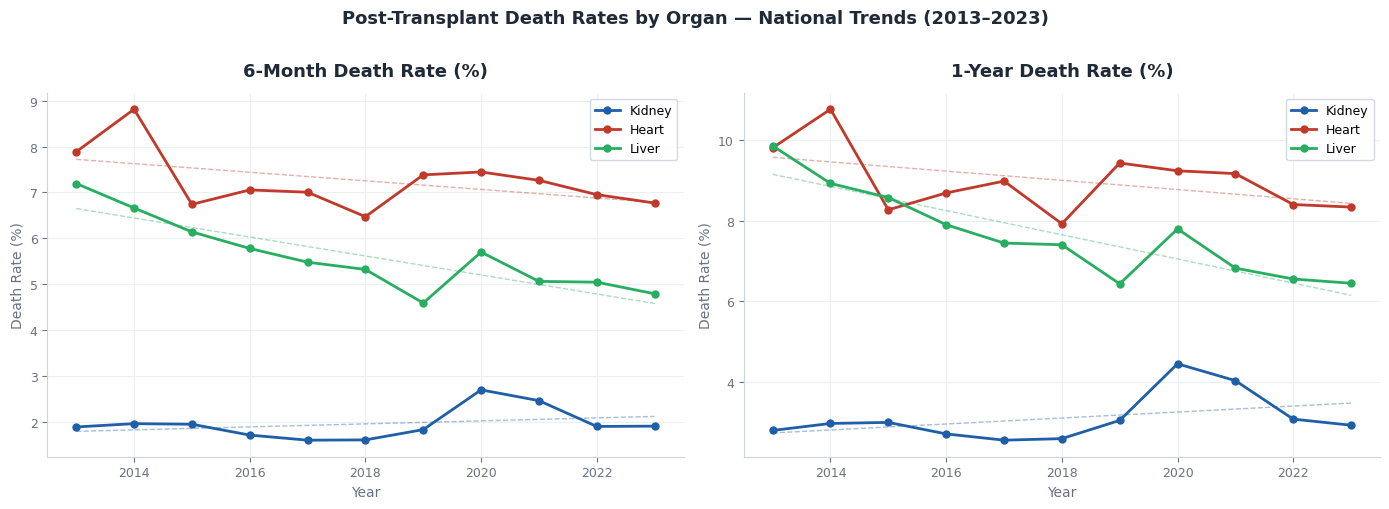

 Chart 1 saved.


In [50]:
# ── Chart 1: National outcome trends ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('white')
fig.suptitle('Post-Transplant Death Rates by Organ — National Trends (2013–2023)',
             fontsize=13, fontweight='bold', color='#1F2937', y=1.01)

for ax, (col, label) in zip(axes, [
        ('death_6mo_pct','6-Month Death Rate (%)'),
        ('death_1yr_pct','1-Year Death Rate (%)')]):
    for organ, color in COLORS.items():
        sub = death_df[death_df['organ']==organ][['Year',col]].dropna().sort_values('Year')
        if sub.empty: continue
        ax.plot(sub['Year'], sub[col], marker='o', markersize=5,
                color=color, linewidth=2, label=organ, zorder=3)
        z = np.polyfit(sub['Year'], sub[col], 1)
        ax.plot(sub['Year'], np.poly1d(z)(sub['Year']),
                color=color, linewidth=1, linestyle='--', alpha=0.4, zorder=2)
    set_style(ax, label, ylabel='Death Rate (%)')
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax.legend(fontsize=9, framealpha=0.9, edgecolor='#CBD5E1')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/charts/01_outcome_trends.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(" Chart 1 saved.")


The DGF control chart — the primary anomaly signal. The shaded band is the rolling ±2 SD range. When the line breaks out of the top of that band it's statistically out of control. The sustained elevation starting in 2020 is the main finding: DGF went from 17.7% in 2013 to 26.7% in 2024, a 51% relative increase in the rate of patients needing dialysis within the first week post-transplant.

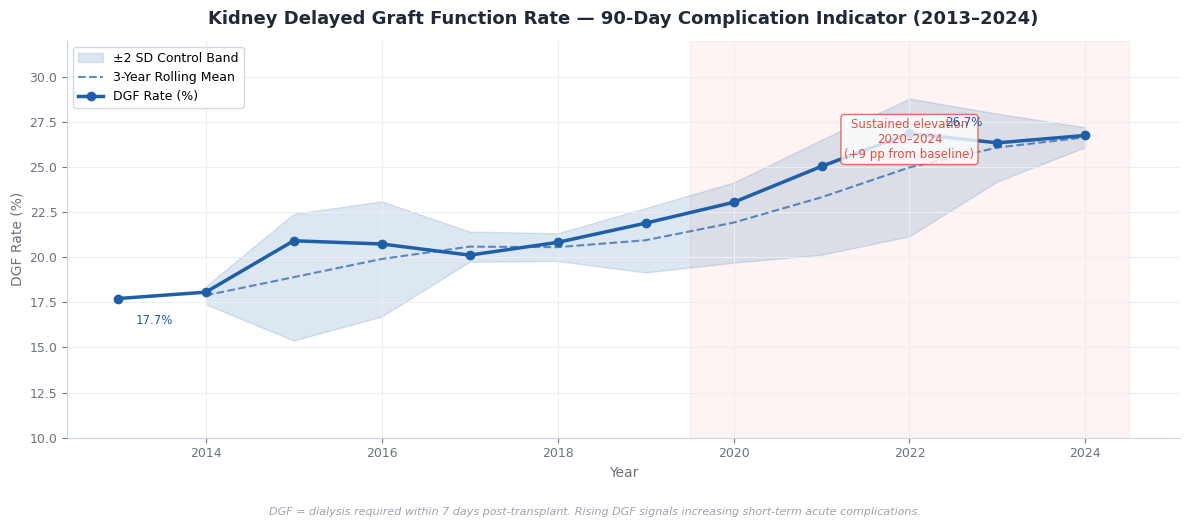

 Chart 2 saved — DGF control chart (primary anomaly signal).


In [51]:
# ── Chart 2: DGF Control Chart — THE YAWAH SIGNAL ────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor('white')

years = dgf['Year'].values
rates = dgf['dgf_rate_pct'].values
trend = dgf_trend.dropna(subset=['rolling_mean'])

ax.fill_between(trend['Year'], trend['lower_limit'], trend['upper_limit'],
                alpha=0.15, color='#1E5FA8', label='±2 SD Control Band', zorder=1)
ax.plot(trend['Year'], trend['rolling_mean'],
        color='#1E5FA8', linewidth=1.5, linestyle='--', alpha=0.7, label='3-Year Rolling Mean', zorder=2)
ax.plot(years, rates, marker='o', markersize=6, color='#1E5FA8',
        linewidth=2.5, label='DGF Rate (%)', zorder=3)

# Shade sustained elevation period
ax.axvspan(2019.5, 2024.5, alpha=0.06, color=RED_F, zorder=0)
ax.annotate('Sustained elevation\n2020–2024\n(+9 pp from baseline)',
            xy=(2022, 25.5), fontsize=8.5, color=RED_F, ha='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=RED_F, alpha=0.8))

ax.annotate(f'{rates[0]:.1f}%', xy=(years[0], rates[0]),
            xytext=(years[0]+0.2, rates[0]-1.4), fontsize=8.5, color='#1E5FA8')
ax.annotate(f'{rates[-1]:.1f}%', xy=(years[-1], rates[-1]),
            xytext=(years[-1]-1.6, rates[-1]+0.5), fontsize=8.5, color='#1E5FA8')

set_style(ax,
    'Kidney Delayed Graft Function Rate — 90-Day Complication Indicator (2013–2024)',
    ylabel='DGF Rate (%)')
ax.set_ylim(10, 32)
ax.legend(fontsize=9, framealpha=0.9, edgecolor='#CBD5E1', loc='upper left')
fig.text(0.5, -0.04,
    'DGF = dialysis required within 7 days post-transplant. '
    'Rising DGF signals increasing short-term acute complications.',
    ha='center', fontsize=8, color='#9CA3AF', style='italic')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/charts/02_dgf_control_chart.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(" Chart 2 saved — DGF control chart (primary anomaly signal).")


Short-term vs long-term divergence scatter. Each point is one year. X axis is 1-year death rate, Y axis is 6-month. The dashed line is the historical ratio — points above it mean 6-month mortality was proportionally higher than expected given 1-year survival. Flagged years are labeled in red.

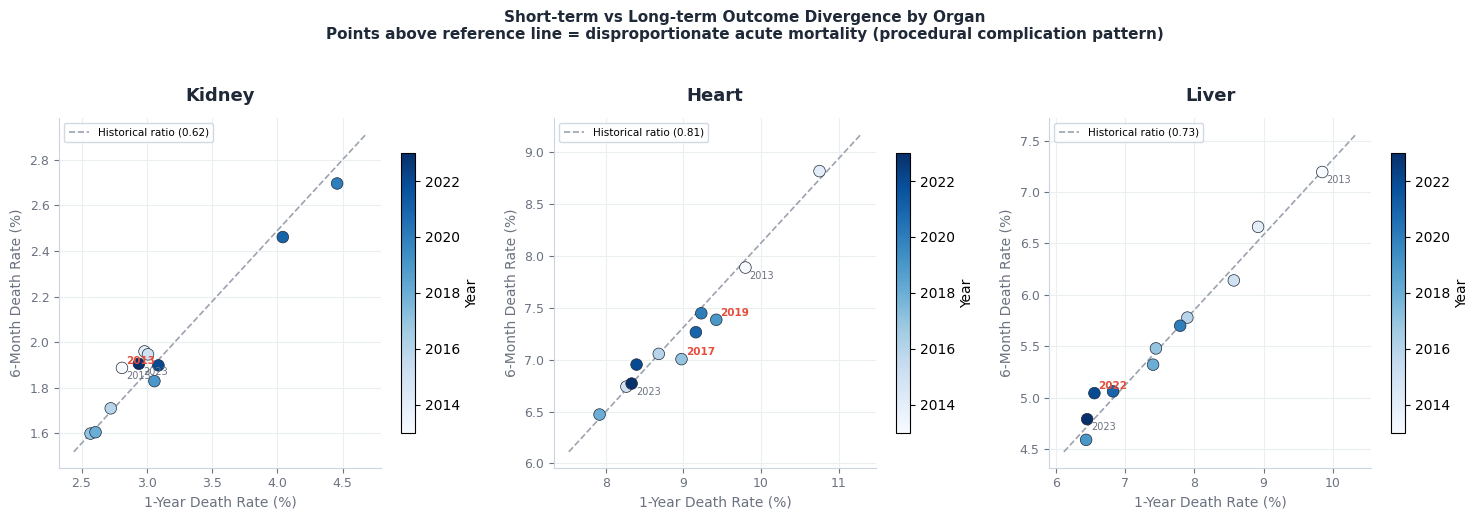

 Chart 3 saved — divergence scatter (flagged years in red).


In [52]:
# ── Chart 3: Short-term vs Long-term Divergence ──────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.patch.set_facecolor('white')
fig.suptitle(
    'Short-term vs Long-term Outcome Divergence by Organ\n'
    'Points above reference line = disproportionate acute mortality (procedural complication pattern)',
    fontsize=11, fontweight='bold', color='#1F2937', y=1.03)

for ax, organ in zip(axes, ['Kidney','Heart','Liver']):
    sub = death_df[death_df['organ']==organ][['Year','death_6mo_pct','death_1yr_pct']].dropna()
    div_sub = div_df[(div_df['organ']==organ) & div_df['divergence_flag']]

    sc = ax.scatter(sub['death_1yr_pct'], sub['death_6mo_pct'],
                    c=sub['Year'], cmap='Blues', s=70, zorder=3,
                    edgecolors='#1F2937', linewidth=0.5)

    x_range= np.linspace(sub['death_1yr_pct'].min()*0.95, sub['death_1yr_pct'].max()*1.05, 50)
    ratio_median = (sub['death_6mo_pct'] / sub['death_1yr_pct']).median()
    ax.plot(x_range, ratio_median*x_range, color='#9CA3AF', linewidth=1.2,
            linestyle='--', label=f'Historical ratio ({ratio_median:.2f})', zorder=2)

    for _, row in div_sub.iterrows():
        ax.annotate(str(int(row['Year'])),
                    xy=(row['death_1yr_pct'], row['death_6mo_pct']),
                    xytext=(3,3), textcoords='offset points',
                    fontsize=7.5, color=RED_F, fontweight='bold')

    for _, row in sub.iterrows():
        if row['Year'] in [sub['Year'].min(), sub['Year'].max()]:
            ax.annotate(str(int(row['Year'])),
                        xy=(row['death_1yr_pct'], row['death_6mo_pct']),
                        xytext=(3,-8), textcoords='offset points',
                        fontsize=7, color='#6B7280')

    plt.colorbar(sc, ax=ax, label='Year', shrink=0.8)
    set_style(ax, organ, xlabel='1-Year Death Rate (%)', ylabel='6-Month Death Rate (%)')
    ax.legend(fontsize=7.5, framealpha=0.9, edgecolor='#CBD5E1')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/charts/03_divergence_scatter.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(" Chart 3 saved — divergence scatter (flagged years in red).")


Annual transplant volumes by organ. The COVID disruption in 2020 is visible across all three. Volume context matters when interpreting outcome rate trends.

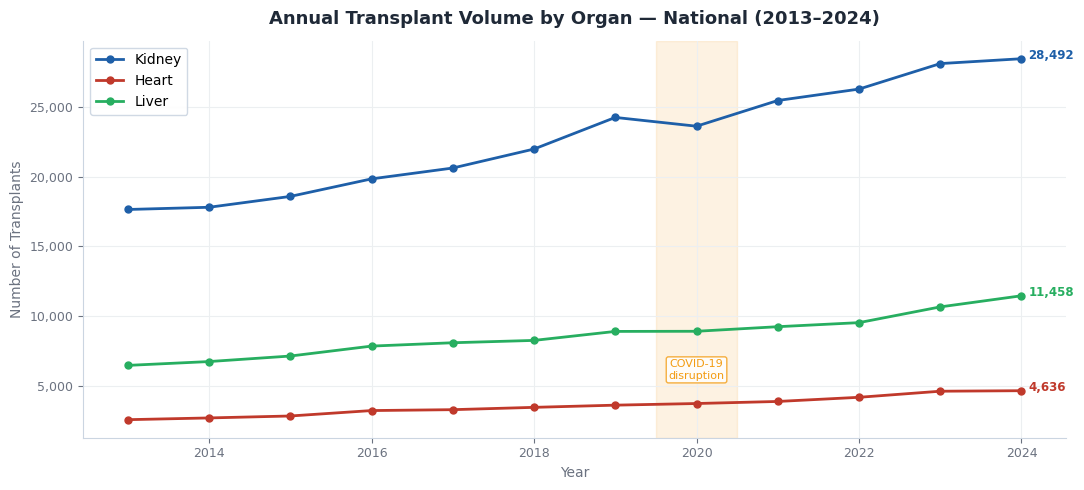

 Chart 4 saved — transplant volumes with COVID annotation.


In [53]:
# ── Chart 4: Transplant Volume Growth ────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor('white')

for organ, color in COLORS.items():
    sub= tx_df[tx_df['organ']==organ].sort_values('Year')
    ax.plot(sub['Year'], sub['tx_count'], marker='o', markersize=5,
            color=color, linewidth=2, label=organ, zorder=3)
    last = sub.iloc[-1]
    ax.annotate(f"{int(last['tx_count']):,}",
                xy=(last['Year'], last['tx_count']),
                xytext=(5,0), textcoords='offset points',
                fontsize=8.5, color=color, fontweight='bold')

ax.axvspan(2019.5, 2020.5, alpha=0.12, color=YEL_F, zorder=0)
ax.annotate('COVID-19\ndisruption', xy=(2020, 5500),
            fontsize=8, color=YEL_F, ha='center',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor=YEL_F, alpha=0.8))

set_style(ax, 'Annual Transplant Volume by Organ — National (2013–2024)',
          ylabel='Number of Transplants')
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(fontsize=10, framealpha=0.9, edgecolor='#CBD5E1')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/charts/04_transplant_volumes.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(" Chart 4 saved — transplant volumes with COVID annotation.")


---
## Power BI / Tableau dashboard

The CSVs in outputs/ feed directly into the dashboard. In Power BI, connect via Get Data > Text/CSV for each file. In Tableau, use Connect > Text File and point it at the same folder.

Suggested table names:

- death_rates_clean.csv -> DeathRates
- tx_counts_clean.csv -> TxVolumes
- dgf_rates_clean.csv -> DGF
- dgf_trend_analysis.csv -> DGFTrend (has the upper/lower control limit columns for the shaded band)
- flagged_signals.csv -> Flags
- waitlist_mortality_clean.csv -> WaitlistMort

The dashboard has four pages. Executive summary with KPI cards for the latest death rates, DGF rate, and total flag count, plus an organ slicer. Outcome trends page with the DGF control chart and the death rate trend lines, with anomaly periods highlighted. Anomaly flags page — a table sorted RED first with conditional formatting on severity. And a data quality monitor page showing missing follow-up rates and when each data element was last validated. That last one is worth building out properly; it shows the team the data is trustworthy before they act on the other three.

---
## Summary

In [54]:
# ── Final summary ─────────────────────────────────────────────────────────
print("=" * 55)
print("PIPELINE COMPLETE")
print("=" * 55)
print(f"\nOutputs saved to: {OUTPUT_DIR}/")
print("\nFiles generated:")
for f in sorted(os.listdir(OUTPUT_DIR)):
    if not os.path.isdir(f'{OUTPUT_DIR}/{f}'):
        size = os.path.getsize(f'{OUTPUT_DIR}/{f}')
        print(f"  {f:<40} {size:>8,} bytes")
print("\nCharts saved to:", f'{OUTPUT_DIR}/charts/')
for f in sorted(os.listdir(f'{OUTPUT_DIR}/charts')):
    print(f"  {f}")


PIPELINE COMPLETE

Outputs saved to: ./outputs/

Files generated:
  data_quality_report.json                    1,626 bytes
  death_rates_clean.csv                       2,368 bytes
  dgf_rates_clean.csv                           772 bytes
  dgf_trend_analysis.csv                      1,716 bytes
  divergence_analysis.csv                     3,252 bytes
  flagged_signals.csv                           920 bytes
  trend_analysis.csv                          9,890 bytes
  tx_counts_clean.csv                           622 bytes
  waitlist_mortality_clean.csv                1,049 bytes

Charts saved to: ./outputs/charts/
  01_outcome_trends.png
  02_dgf_control_chart.png
  03_divergence_scatter.png
  04_transplant_volumes.png
